# CIFAR-100 — Transfer Learning with ResNet-34

Fine-tuning a pre-trained ResNet-34 (ImageNet weights) on CIFAR-10.

**Strategy:**
- Resize CIFAR-10 images from 32×32 → 224×224 (ImageNet standard)
- Load `resnet34(weights='DEFAULT')` with pre-trained weights
- Replace the final FC layer for 10 classes
- Fine-tune with SGD + OneCycleLR (lower max_lr since weights are already good)
- Use `ModelCheckpoint` for crash protection & best model saving

## Imports

In [10]:
import sys
sys.path.append('../..')

import torch
import torch.nn as nn
import torchvision.models as models
from torch import optim

from utils.dataset import get_cifar100_dataloaders, CIFAR100_CLASSES
from utils.training import fit, test_accuracy
from utils.callbacks import ModelCheckpoint
from utils.plotting import plot_training_curves, show_sample_batch

## Device Setup

In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True
print(f'Using device: {device}')

Using device: cuda


## Data Pipeline

Since the pre-trained ResNet-34 was trained on 224×224 ImageNet images,
we resize CIFAR-10 images to 224×224 to match the expected input resolution.
We use ImageNet normalization stats since the backbone was pre-trained with them.

In [12]:
batch_size = 64  # Smaller batch for 224×224 images

trainloader, valloader, testloader = get_cifar100_dataloaders(
    batch_size=batch_size,
    num_workers=4,
    img_size=224,
    use_imagenet_stats=True,
)

print(f'Train batches: {len(trainloader)} | Val batches: {len(valloader)} | Test batches: {len(testloader)}')

Train batches: 625 | Val batches: 157 | Test batches: 157


## Visualize Sample Batch

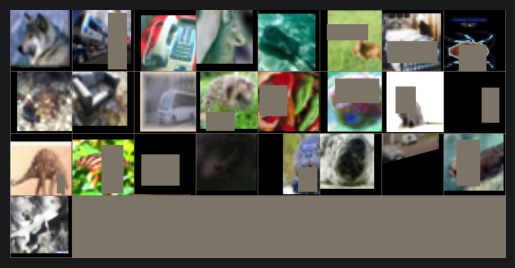

wolf  train telephone kangaroo ray   cattle bed   cockroach ray   couch bus   porcupine sweet_pepper apple possum bicycle dinosaur butterfly mouse spider beaver seal  castle seal  lizard


In [13]:
show_sample_batch(trainloader, CIFAR100_CLASSES, n=25)

## Model: Pre-trained ResNet-34

We load the ResNet-34 backbone with ImageNet weights,
then replace the final fully connected layer to output 10 classes.

The `BasicBlock` structure is identical to our custom ResNet-18,
but ResNet-34 is deeper (34 layers vs 18), giving it more capacity
to learn complex features — all while keeping the same lightweight block design.

In [14]:
model = models.resnet34(weights='DEFAULT')

# Replace the final FC layer (1000 classes → 100 for CIFAR-100)
num_features = model.fc.in_features  # 512
model.fc = nn.Linear(num_features, 100)

model.to(device)
print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')

Model parameters: 21,335,972


## Training Configuration

Since the backbone is already pre-trained, we use a **lower max learning rate** (`0.01`)
compared to training from scratch (`0.1`). This prevents the fine-tuning from
destroying the pre-trained features.

In [15]:
criterion = nn.CrossEntropyLoss()
epochs = 45
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.01,
    steps_per_epoch=len(trainloader),
    epochs=epochs,
    pct_start=0.3,
    anneal_strategy='cos',
    div_factor=10,
    final_div_factor=1e3,
)

scaler = torch.amp.GradScaler('cuda')
NAME = 'resnet34_transfer_100'
checkpoint = ModelCheckpoint(
    model=model,
    checkpoint_path=f'../../checkpoint/{NAME}_latest.pth',
    best_model_path=f'../../checkpoint/{NAME}_best.pth',
    mode='max',
    verbose=True,
)

## Training Loop

In [16]:
train_losses, val_losses, val_accuracies = fit(
    model, trainloader, valloader, criterion,
    optimizer, scheduler, scaler, device, epochs, checkpoint,
)

[ModelCheckpoint] New best (max): 68.3100 — saved to ..\checkpoint\resnet34_transfer_100_best.pth
Epoch [ 1/45]  Train Loss: 2.7380  Val Loss: 1.0970  Val Acc: 68.31%  LR: 0.001121  Time: 34.35s
[ModelCheckpoint] New best (max): 72.8100 — saved to ..\checkpoint\resnet34_transfer_100_best.pth
Epoch [ 2/45]  Train Loss: 1.4786  Val Loss: 0.8968  Val Acc: 72.81%  LR: 0.001479  Time: 26.36s
[ModelCheckpoint] New best (max): 75.0700 — saved to ..\checkpoint\resnet34_transfer_100_best.pth
Epoch [ 3/45]  Train Loss: 1.2832  Val Loss: 0.8173  Val Acc: 75.07%  LR: 0.002053  Time: 26.44s
Epoch [ 4/45]  Train Loss: 1.1948  Val Loss: 0.8319  Val Acc: 74.57%  LR: 0.002813  Time: 26.31s
Epoch [ 5/45]  Train Loss: 1.1603  Val Loss: 0.8481  Val Acc: 74.56%  LR: 0.003718  Time: 26.24s
Epoch [ 6/45]  Train Loss: 1.1182  Val Loss: 0.8771  Val Acc: 74.67%  LR: 0.004719  Time: 26.46s
Epoch [ 7/45]  Train Loss: 1.0877  Val Loss: 0.9779  Val Acc: 72.16%  LR: 0.005763  Time: 26.29s
Epoch [ 8/45]  Train Loss: 

## Restore Best Weights & Test Evaluation

In [17]:
checkpoint.restore_best_weights()

overall_acc, per_class = test_accuracy(model, testloader, CIFAR100_CLASSES, device)
print(f'\nOverall Test Accuracy: {overall_acc:.2f}%\n')
for name, acc in per_class.items():
    print(f'  {name:5s}: {acc:.1f}%')

[ModelCheckpoint] Restored best weights from ..\checkpoint\resnet34_transfer_100_best.pth (score=84.7300)

Overall Test Accuracy: 85.03%

  apple: 95.0%
  aquarium_fish: 95.0%
  baby : 74.0%
  bear : 80.0%
  beaver: 74.0%
  bed  : 85.0%
  bee  : 83.0%
  beetle: 84.0%
  bicycle: 96.0%
  bottle: 91.0%
  bowl : 63.0%
  boy  : 58.0%
  bridge: 86.0%
  bus  : 83.0%
  butterfly: 92.0%
  camel: 91.0%
  can  : 85.0%
  castle: 89.0%
  caterpillar: 88.0%
  cattle: 83.0%
  chair: 93.0%
  chimpanzee: 95.0%
  clock: 90.0%
  cloud: 83.0%
  cockroach: 90.0%
  couch: 83.0%
  crab : 84.0%
  crocodile: 81.0%
  cup  : 91.0%
  dinosaur: 85.0%
  dolphin: 85.0%
  elephant: 91.0%
  flatfish: 80.0%
  forest: 73.0%
  fox  : 89.0%
  girl : 62.0%
  hamster: 91.0%
  house: 81.0%
  kangaroo: 87.0%
  keyboard: 93.0%
  lamp : 87.0%
  lawn_mower: 89.0%
  leopard: 86.0%
  lion : 94.0%
  lizard: 83.0%
  lobster: 83.0%
  man  : 76.0%
  maple_tree: 66.0%
  motorcycle: 98.0%
  mountain: 92.0%
  mouse: 68.0%
  mushroom: 91.

## Training Curves

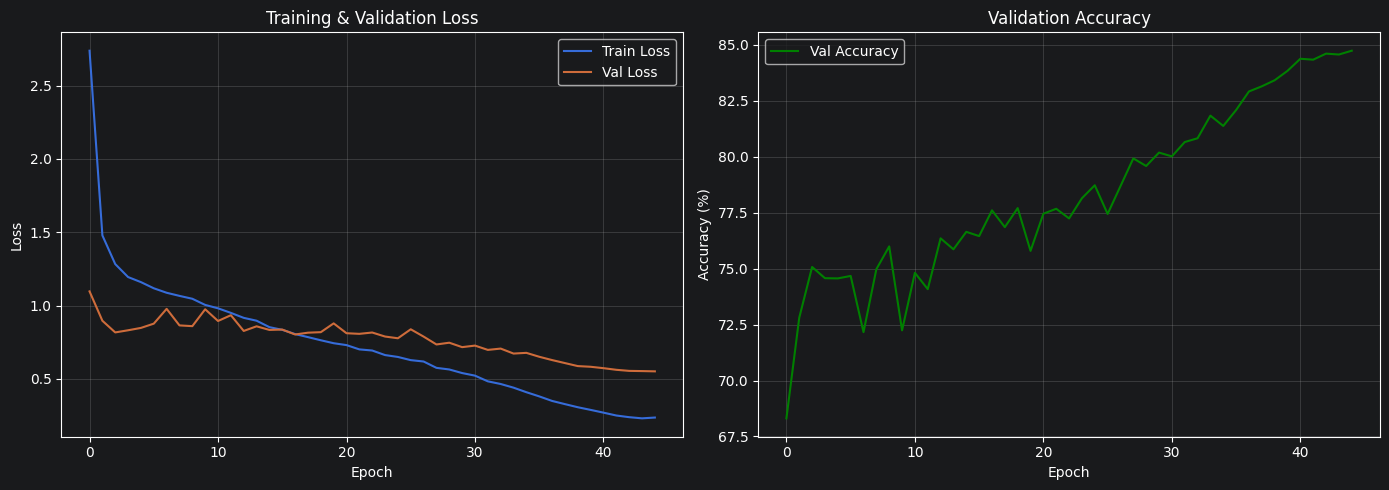

In [18]:
plot_training_curves(train_losses, val_losses, val_accuracies)